<a href="https://colab.research.google.com/github/oamerciful-rgb/Urban-Mobility-Intelligence-Unit-/blob/main/Artificial_Intelligence_and_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import time, json

tf.random.set_seed(42)
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: []


In [ ]:
CSV_PATH = "/content/Stock_Price_Data_[3921] (1) (1).csv"   # match the exact filename you uploaded

df = pd.read_csv(CSV_PATH, parse_dates=["Date"], dayfirst=True)
df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicated dates:", df["Date"].duplicated().sum())
df.describe()

Shape: (9909, 7)
Date range: 1980-12-12 00:00:00 to 2020-04-01 00:00:00

Missing values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicated dates: 0


,Date,Open,High,Low,Close,Adj Close,Volume
count,9909,9909.000000,9909.000000,9909.000000,9909.000000,9909.000000,9.909000e+03
mean,2000-07-30 08:33:08.010899200,32.606849,32.936079,32.277560,32.618030,30.576570,8.582916e+07
min,1980-12-12 00:00:00,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05
25%,1990-10-02 00:00:00,1.071429,1.089286,1.048571,1.071429,0.917643,3.304230e+07
50%,2000-07-21 00:00:00,1.729286,1.758929,1.696429,1.732143,1.466154,5.766490e+07
75%,2010-05-28 00:00:00,35.799999,36.265713,35.328571,35.761429,31.042374,1.069992e+08
max,2020-04-01 00:00:00,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09
std,NaN,58.415759,59.001576,57.883037,58.471899,56.746275,8.597195e+07


In [ ]:
print(df.isnull().sum())
print("Duplicate dates:", df["Date"].duplicated().sum())
df.describe()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Duplicate dates: 0


,Date,Open,High,Low,Close,Adj Close,Volume
count,9909,9909.000000,9909.000000,9909.000000,9909.000000,9909.000000,9.909000e+03
mean,2000-07-30 08:33:08.010899200,32.606849,32.936079,32.277560,32.618030,30.576570,8.582916e+07
min,1980-12-12 00:00:00,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05
25%,1990-10-02 00:00:00,1.071429,1.089286,1.048571,1.071429,0.917643,3.304230e+07
50%,2000-07-21 00:00:00,1.729286,1.758929,1.696429,1.732143,1.466154,5.766490e+07
75%,2010-05-28 00:00:00,35.799999,36.265713,35.328571,35.761429,31.042374,1.069992e+08
max,2020-04-01 00:00:00,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09
std,NaN,58.415759,59.001576,57.883037,58.471899,56.746275,8.597195e+07


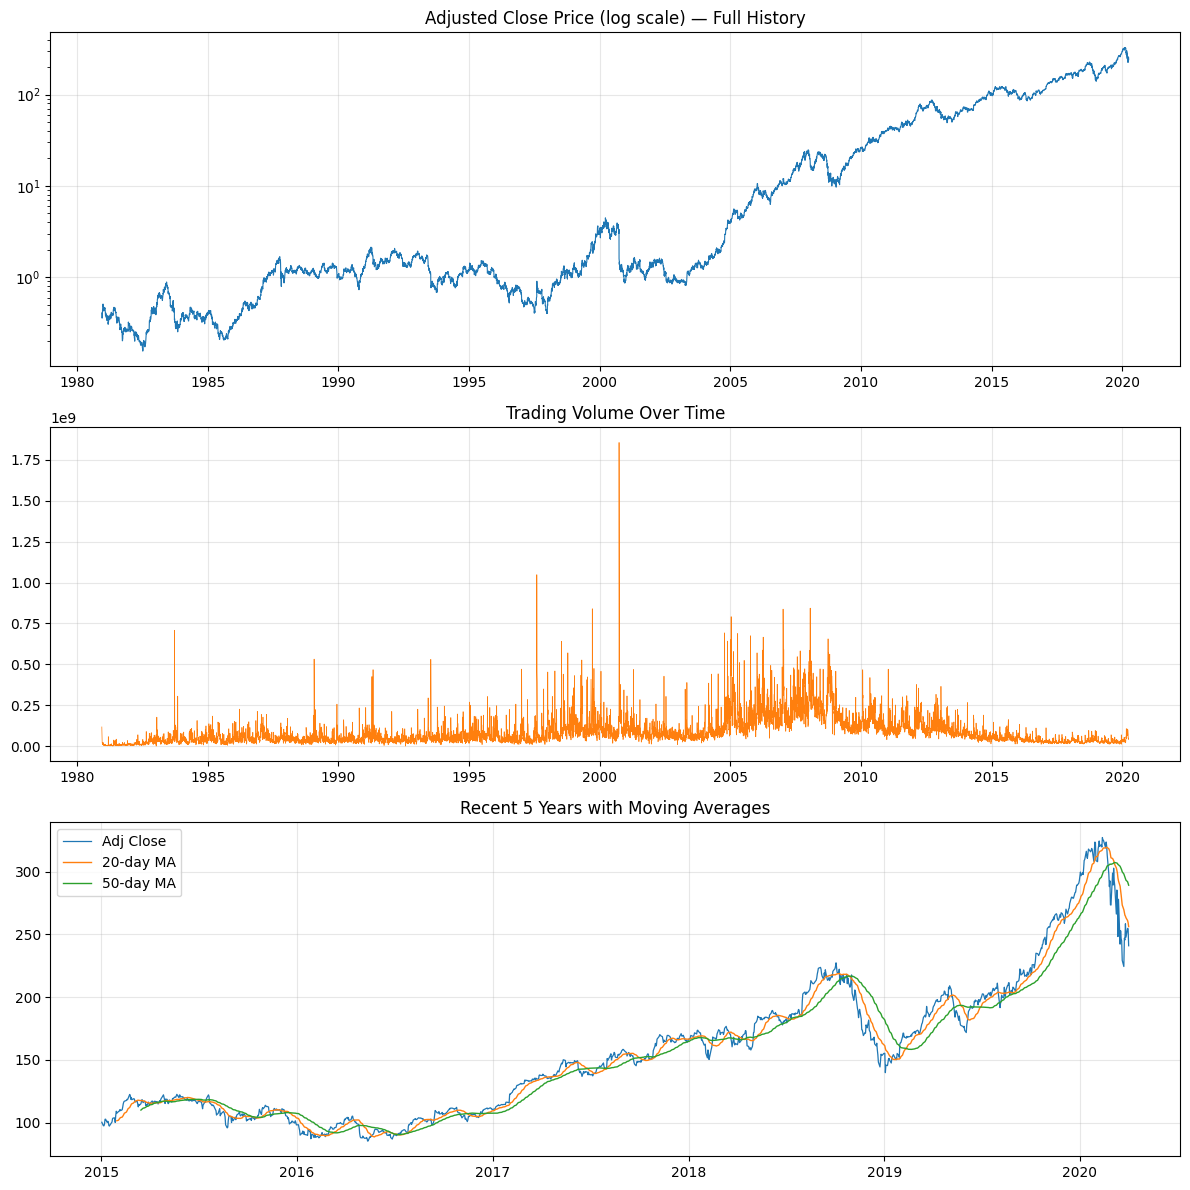

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

axes[0].plot(df["Date"], df["Adj Close"], color="#1f77b4", linewidth=0.8)
axes[0].set_yscale("log")
axes[0].set_title("Adjusted Close Price (log scale) — Full History")
axes[0].grid(alpha=0.3)

axes[1].plot(df["Date"], df["Volume"], color="#ff7f0e", linewidth=0.5)
axes[1].set_title("Trading Volume Over Time")
axes[1].grid(alpha=0.3)

recent = df[df["Date"] >= "2015-01-01"].copy()
recent["MA20"] = recent["Adj Close"].rolling(20).mean()
recent["MA50"] = recent["Adj Close"].rolling(50).mean()
axes[2].plot(recent["Date"], recent["Adj Close"], label="Adj Close", linewidth=0.9)
axes[2].plot(recent["Date"], recent["MA20"], label="20-day MA", linewidth=1)
axes[2].plot(recent["Date"], recent["MA50"], label="50-day MA", linewidth=1)
axes[2].set_title("Recent 5 Years with Moving Averages")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
df["split_ratio"] = df["Close"] / df["Adj Close"]
print(df["split_ratio"].round(3).drop_duplicates().values)

[1.262 1.26  1.259 1.256 1.253 1.251 1.248 1.245 1.242 1.239 1.236 1.233
 1.229 1.226 1.222 1.218 1.215 1.212 1.21  1.207 1.204 1.202 1.199 1.196
 1.194 1.191 1.186 1.182 1.177 1.173 1.169 1.165 1.162 1.159 1.156 1.152
 1.147 1.142 1.135 1.128 1.12  1.114 1.107 1.101 1.096 1.091 1.087 1.082
 1.077 1.073 1.067 1.06  1.055 1.049 1.045 1.04  1.036 1.033 1.029 1.025
 1.021 1.017 1.013 1.009 1.005 1.002 1.   ]


In [ ]:
FEATURE_COLS = ["Open", "High", "Low", "Close", "Volume"]
TARGET_COL = "Close"

def fit_scalers(train_df):
    feat_scaler = MinMaxScaler()
    feat_scaler.fit(train_df[FEATURE_COLS])
    target_scaler = MinMaxScaler()
    target_scaler.fit(train_df[[TARGET_COL]])
    return feat_scaler, target_scaler

def scale_split(split_df, feat_scaler, target_scaler):
    feats = feat_scaler.transform(split_df[FEATURE_COLS])
    target = target_scaler.transform(split_df[[TARGET_COL]])
    return feats, target

In [ ]:
def chronological_split(df, train_frac=0.80, val_frac=0.10):
    n = len(df)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = chronological_split(df)
print("Train:", train_df["Date"].min(), "-", train_df["Date"].max())
print("Val:  ", val_df["Date"].min(), "-", val_df["Date"].max())
print("Test: ", test_df["Date"].min(), "-", test_df["Date"].max())

Train: 1980-12-12 00:00:00 - 2012-05-15 00:00:00
Val:   2012-05-16 00:00:00 - 2016-04-25 00:00:00
Test:  2016-04-26 00:00:00 - 2020-04-01 00:00:00


In [ ]:
def make_sequences(features, target, seq_len):
    X, y = [], []
    for i in range(seq_len, len(features)):
        X.append(features[i - seq_len:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

In [ ]:
def build_dataset(df, seq_len):
    train_df, val_df, test_df = chronological_split(df)
    feat_scaler, target_scaler = fit_scalers(train_df)

    def with_lookback(main_df, prev_df):
        lookback = prev_df.iloc[-seq_len:]
        return pd.concat([lookback, main_df], axis=0)

    train_feats, train_target = scale_split(train_df, feat_scaler, target_scaler)
    X_train, y_train = make_sequences(train_feats, train_target, seq_len)

    val_lb = with_lookback(val_df, train_df)
    val_feats, val_target = scale_split(val_lb, feat_scaler, target_scaler)
    X_val, y_val = make_sequences(val_feats, val_target, seq_len)

    test_lb = with_lookback(test_df, val_df)
    test_feats, test_target = scale_split(test_lb, feat_scaler, target_scaler)
    X_test, y_test = make_sequences(test_feats, test_target, seq_len)

    return X_train, y_train, X_val, y_val, X_test, y_test, feat_scaler, target_scaler

X_train, y_train, X_val, y_val, X_test, y_test, feat_scaler, target_scaler = build_dataset(df, seq_len=30)
print(X_train.shape, y_train.shape)

(7897, 30, 5) (7897,)


In [ ]:
def build_lstm(seq_len, n_features, units=50, dropout=0.2, layers=1, lr=0.001):
    model = Sequential(name="LSTM_model")
    model.add(Input(shape=(seq_len, n_features)))
    for i in range(layers):
        model.add(LSTM(units, return_sequences=(i < layers - 1)))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

In [ ]:
def get_early_stopping(patience=5):
    return EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)

In [ ]:
FEATURE_COLS = ["Open", "High", "Low", "Close", "Volume"]
TARGET_COL = "Close"

def fit_scalers(train_df):
    feat_scaler = MinMaxScaler()
    feat_scaler.fit(train_df[FEATURE_COLS])
    target_scaler = MinMaxScaler()
    target_scaler.fit(train_df[[TARGET_COL]])
    return feat_scaler, target_scaler

def scale_split(split_df, feat_scaler, target_scaler):
    feats = feat_scaler.transform(split_df[FEATURE_COLS])
    target = target_scaler.transform(split_df[[TARGET_COL]])
    return feats, target

def chronological_split(df, train_frac=0.80, val_frac=0.10):
    n = len(df)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

def make_sequences(features, target, seq_len):
    X, y = [], []
    for i in range(seq_len, len(features)):
        X.append(features[i - seq_len:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

def build_dataset(df, seq_len):
    train_df, val_df, test_df = chronological_split(df)
    feat_scaler, target_scaler = fit_scalers(train_df)

    def with_lookback(main_df, prev_df):
        lookback = prev_df.iloc[-seq_len:]
        return pd.concat([lookback, main_df], axis=0)

    train_feats, train_target = scale_split(train_df, feat_scaler, target_scaler)
    X_train, y_train = make_sequences(train_feats, train_target, seq_len)

    val_lb = with_lookback(val_df, train_df)
    val_feats, val_target = scale_split(val_lb, feat_scaler, target_scaler)
    X_val, y_val = make_sequences(val_feats, val_target, seq_len)

    test_lb = with_lookback(test_df, val_df)
    test_feats, test_target = scale_split(test_lb, feat_scaler, target_scaler)
    X_test, y_test = make_sequences(test_feats, test_target, seq_len)

    return X_train, y_train, X_val, y_val, X_test, y_test, feat_scaler, target_scaler


In [ ]:
# LSTM-A: 1 layer, 50 units, 0.2 dropout, 30-day window
X_train, y_train, X_val, y_val, X_test, y_test, feat_scaler, target_scaler = build_dataset(df, seq_len=30)

lstm_a = build_lstm(seq_len=30, n_features=X_train.shape[2], units=50, dropout=0.2, layers=1)
history_lstm_a = lstm_a.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=32,
    callbacks=[get_early_stopping(5)],
    verbose=1
)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0013 - mae: 0.0152 - val_loss: 0.0020 - val_mae: 0.0350
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.3304e-04 - mae: 0.0087 - val_loss: 0.0113 - val_mae: 0.0934
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.6683e-04 - mae: 0.0073 - val_loss: 9.1394e-04 - val_mae: 0.0241
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.5047e-04 - mae: 0.0075 - val_loss: 7.6389e-04 - val_mae: 0.0218
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.2562e-04 - mae: 0.0073 - val_loss: 0.0013 - val_mae: 0.0273
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.8259e-04 - mae: 0.0065 - val_loss: 7.2368e-04 - val_mae: 0.0212
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.0174e-04 - mae: 0.0067 - val_loss: 7.4709e-04 - val_mae: 0.0214
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.8994e-04 - mae: 0.0070 - val_loss: 6.9405e-04 - val_mae: 0.0208
Epoch 

In [ ]:
# LSTM-B: 2 layers, 64 units, 0.3 dropout, 60-day window
X_train60, y_train60, X_val60, y_val60, X_test60, y_test60, feat_scaler60, target_scaler60 = build_dataset(df, seq_len=60)

lstm_b = build_lstm(seq_len=60, n_features=X_train60.shape[2], units=64, dropout=0.3, layers=2)
history_lstm_b = lstm_b.fit(
    X_train60, y_train60,
    validation_data=(X_val60, y_val60),
    epochs=30, batch_size=32,
    callbacks=[get_early_stopping(5)],
    verbose=1
)

Epoch 1/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 7.7943e-04 - mae: 0.0129 - val_loss: 0.0090 - val_mae: 0.0791
Epoch 2/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 4.4328e-04 - mae: 0.0105 - val_loss: 0.0048 - val_mae: 0.0525
Epoch 3/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - loss: 4.2967e-04 - mae: 0.0098 - val_loss: 0.0073 - val_mae: 0.0730
Epoch 4/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 4.4801e-04 - mae: 0.0105 - val_loss: 0.0033 - val_mae: 0.0494
Epoch 5/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 3.5091e-04 - mae: 0.0092 - val_loss: 0.0054 - val_mae: 0.0668
Epoch 6/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 3.7080e-04 - mae: 0.0096 - val_loss: 0.0302 - val_mae: 0.1613
Epoch 7/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 4.9571e-04 - mae: 0.0112 - val_loss: 0.0130 - val_mae: 0.1004
Epoch 8/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 3.6885e-04 - mae: 0.0100 - val_loss: 0.0014 - val_mae: 0.0308
Epoch 9/3

In [ ]:
print("LSTM-A trained for", len(history_lstm_a.history["loss"]), "epochs")
print("LSTM-B trained for", len(history_lstm_b.history["loss"]), "epochs")

LSTM-A trained for 13 epochs
LSTM-B trained for 13 epochs


In [ ]:
def build_gru(seq_len, n_features, units=50, dropout=0.2, layers=1, lr=0.001):
    model = Sequential(name="GRU_model")
    model.add(Input(shape=(seq_len, n_features)))
    for i in range(layers):
        model.add(GRU(units, return_sequences=(i < layers - 1)))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

In [ ]:
# GRU-A: 1 layer, 50 units, 0.2 dropout, 30-day window
# (reuses X_train, X_val etc. from seq_len=30 — already built earlier)

gru_a = build_gru(seq_len=30, n_features=X_train.shape[2], units=50, dropout=0.2, layers=1)
history_gru_a = gru_a.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30, batch_size=32,
    callbacks=[get_early_stopping(5)],
    verbose=1
)

Epoch 1/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0011 - mae: 0.0158 - val_loss: 0.0047 - val_mae: 0.0604
Epoch 2/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 3.7190e-04 - mae: 0.0099 - val_loss: 8.0056e-04 - val_mae: 0.0229
Epoch 3/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 2.5469e-04 - mae: 0.0078 - val_loss: 5.7963e-04 - val_mae: 0.0184
Epoch 4/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 2.1511e-04 - mae: 0.0069 - val_loss: 7.1210e-04 - val_mae: 0.0213
Epoch 5/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.4626e-04 - mae: 0.0081 - val_loss: 4.6774e-04 - val_mae: 0.0164
Epoch 6/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.2281e-04 - mae: 0.0075 - val_loss: 8.7851e-04 - val_mae: 0.0245
Epoch 7/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.7470e-04 - mae: 0.0067 - val_loss: 0.0026 - val_mae: 0.0452
Epoch 8/30
247/247 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 2.0342e-04 - mae: 0.0072 - val_loss: 0.0010 - val_mae: 0.0251


In [ ]:
# GRU-B: 2 layers, 64 units, 0.3 dropout, 60-day window
# (reuses X_train60, X_val60 etc. from seq_len=60 — already built earlier)

gru_b = build_gru(seq_len=60, n_features=X_train60.shape[2], units=64, dropout=0.3, layers=2)
history_gru_b = gru_b.fit(
    X_train60, y_train60,
    validation_data=(X_val60, y_val60),
    epochs=30, batch_size=32,
    callbacks=[get_early_stopping(5)],
    verbose=1
)

Epoch 1/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - loss: 0.0011 - mae: 0.0162 - val_loss: 9.7088e-04 - val_mae: 0.0242
Epoch 2/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 5.0623e-04 - mae: 0.0121 - val_loss: 6.7577e-04 - val_mae: 0.0203
Epoch 3/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - loss: 3.9964e-04 - mae: 0.0104 - val_loss: 9.7982e-04 - val_mae: 0.0246
Epoch 4/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 4.2822e-04 - mae: 0.0109 - val_loss: 0.0033 - val_mae: 0.0516
Epoch 5/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - loss: 4.2338e-04 - mae: 0.0111 - val_loss: 0.0011 - val_mae: 0.0268
Epoch 6/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 4.5321e-04 - mae: 0.0114 - val_loss: 0.0012 - val_mae: 0.0275
Epoch 7/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - loss: 3.5722e-04 - mae: 0.0101 - val_loss: 0.0053 - val_mae: 0.0667


In [ ]:
print("GRU-A trained for", len(history_gru_a.history["loss"]), "epochs")
print("GRU-B trained for", len(history_gru_b.history["loss"]), "epochs")

GRU-A trained for 23 epochs
GRU-B trained for 7 epochs


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Rebuild test sets + scalers ONLY — NOT the models
_, _, _, _, X_test_30, y_test_30, _, target_scaler_30 = build_dataset(df, seq_len=30)
_, _, _, _, X_test_60, y_test_60, _, target_scaler_60 = build_dataset(df, seq_len=60)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

trained = {
    "LSTM-A": (lstm_a, 30, 50, 1, 0.2, X_test_30, y_test_30, target_scaler_30),
    "LSTM-B": (lstm_b, 60, 64, 2, 0.3, X_test_60, y_test_60, target_scaler_60),
    "GRU-A":  (gru_a,  30, 50, 1, 0.2, X_test_30, y_test_30, target_scaler_30),
    "GRU-B":  (gru_b,  60, 64, 2, 0.3, X_test_60, y_test_60, target_scaler_60),
}

results = []
predictions = {}
for name, (model, seq_len, units, layers, dropout, Xt, yt, scaler) in trained.items():
    y_pred_scaled = model.predict(Xt, verbose=0).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler.inverse_transform(yt.reshape(-1, 1)).flatten()
    predictions[name] = {"y_true": y_true, "y_pred": y_pred}
    results.append({
        "name": name, "seq_len": seq_len, "units": units, "layers": layers, "dropout": dropout,
        "RMSE": round(rmse(y_true, y_pred), 3),
        "MAE": round(mean_absolute_error(y_true, y_pred), 3),
        "MAPE": round(mape(y_true, y_pred), 3),
    })

results_df = pd.DataFrame(results)
results_df

,name,seq_len,units,layers,dropout,RMSE,MAE,MAPE
0,LSTM-A,30,50,1,0.2,22.139,14.922,6.946
1,LSTM-B,60,64,2,0.3,42.911,29.481,13.671
2,GRU-A,30,50,1,0.2,9.978,6.048,2.773
3,GRU-B,60,64,2,0.3,16.248,11.150,5.299


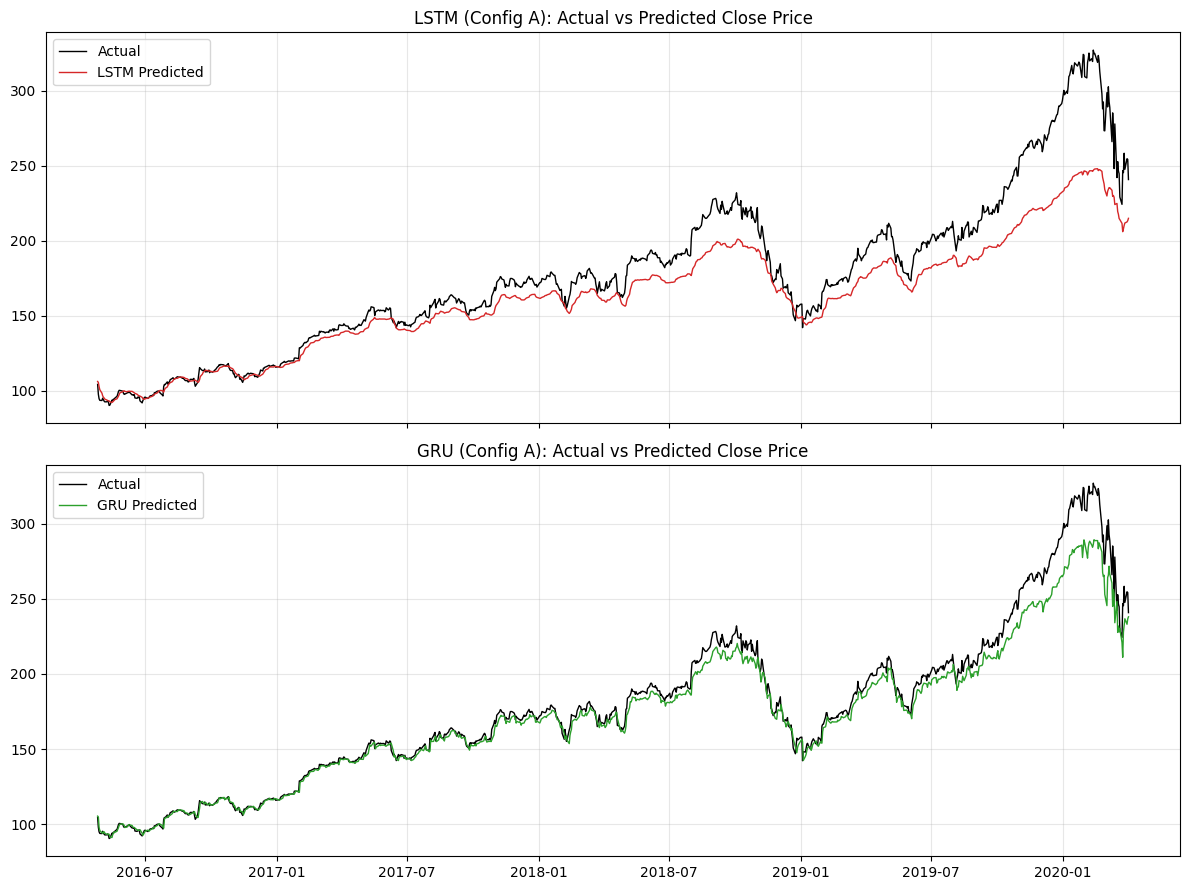

In [ ]:
train_df, val_df, test_df = chronological_split(df)
test_dates = pd.to_datetime(test_df["Date"].values)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
axes[0].plot(test_dates, predictions["LSTM-A"]["y_true"], label="Actual", color="black", linewidth=1)
axes[0].plot(test_dates, predictions["LSTM-A"]["y_pred"], label="LSTM Predicted", color="#d62728", linewidth=1)
axes[0].set_title("LSTM (Config A): Actual vs Predicted Close Price"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(test_dates, predictions["GRU-A"]["y_true"], label="Actual", color="black", linewidth=1)
axes[1].plot(test_dates, predictions["GRU-A"]["y_pred"], label="GRU Predicted", color="#2ca02c", linewidth=1)
axes[1].set_title("GRU (Config A): Actual vs Predicted Close Price"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

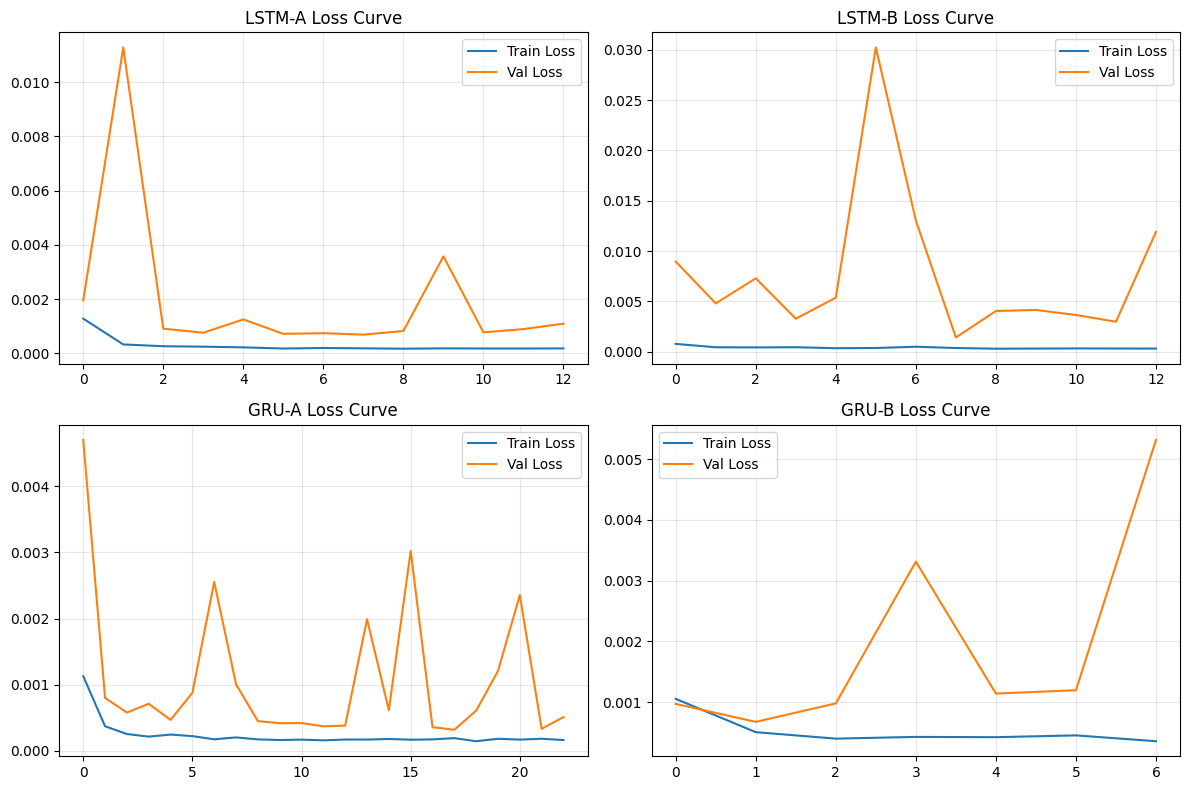

In [ ]:
# Loss curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
hist_map = {"LSTM-A": history_lstm_a, "LSTM-B": history_lstm_b, "GRU-A": history_gru_a, "GRU-B": history_gru_b}
for ax, name in zip(axes.flat, hist_map.keys()):
    h = hist_map[name].history
    ax.plot(h["loss"], label="Train Loss")
    ax.plot(h["val_loss"], label="Val Loss")
    ax.set_title(f"{name} Loss Curve"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

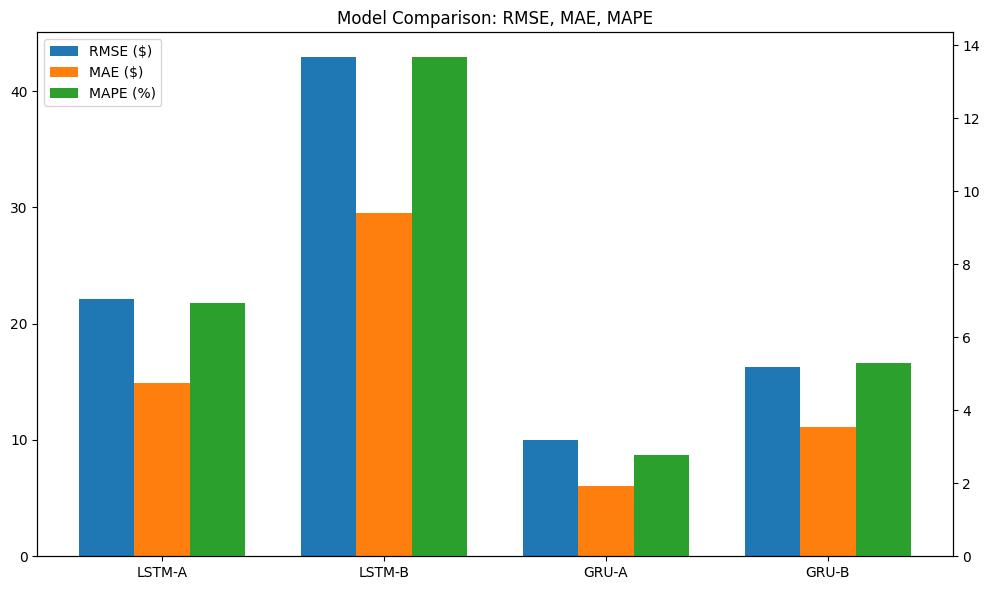

In [ ]:
# Comparison chart
names = results_df["name"]
x = np.arange(len(names)); width = 0.25
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(x - width, results_df["RMSE"], width, label="RMSE ($)", color="#1f77b4")
ax1.bar(x, results_df["MAE"], width, label="MAE ($)", color="#ff7f0e")
ax1.set_xticks(x); ax1.set_xticklabels(names)
ax2 = ax1.twinx()
ax2.bar(x + width, results_df["MAPE"], width, label="MAPE (%)", color="#2ca02c")
l1, lab1 = ax1.get_legend_handles_labels(); l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc="upper left")
plt.title("Model Comparison: RMSE, MAE, MAPE"); plt.tight_layout(); plt.show()